<a href="https://colab.research.google.com/github/iNuman/PytorchDeepLearnignPlayGround/blob/main/PytorchPlayGround.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import seaborn as sns

In [13]:
#%% data import
cars_file = 'https://gist.githubusercontent.com/noamross/e5d3e859aa0c794be10b/raw/b999fb4425b54c63cab088c0ce2c0d6ce961a563/cars.csv'
cars = pd.read_csv(cars_file)
cars.head()


,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


<Axes: xlabel='wt', ylabel='mpg'>

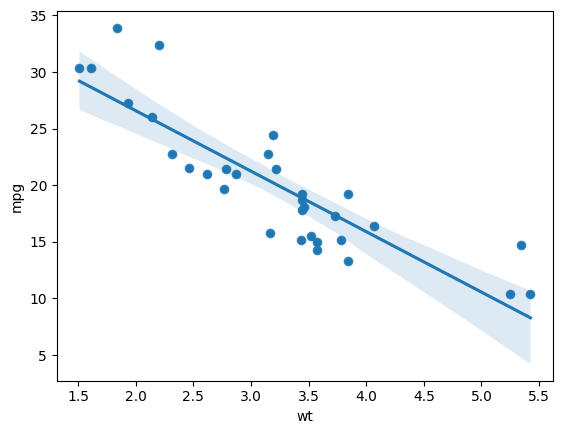

In [14]:
#%% visualise the model
sns.scatterplot(x='wt', y='mpg', data=cars)
sns.regplot(x='wt', y='mpg', data=cars)

# convert data to tensor

In [15]:
X_list = cars.wt.values
X_np = np.array(X_list, dtype=np.float32).reshape(-1,1)
y_list = cars.mpg.values.tolist()
y_np = np.array(y_list, dtype=np.float32).reshape(-1,1)
X = torch.from_numpy(X_np)
y = torch.tensor(y_list)

#training

In [16]:
w = torch.rand(1, requires_grad=True, dtype=torch.float64)
b = torch.rand(1, requires_grad=True, dtype=torch.float64)

num_epochs = 100
learning_rate = 1e-3
for epoch in range(num_epochs):
  for i in range(len(X)):
    # x, y = torch.tensor(X_list[i]), torch.tensor(y_list[i])
    # forward pass
    y_predict = X[i] * w + b
    # calculate loss
    loss_tensor = torch.pow(y_predict - y[i], 2)
    # backward pass
    loss_tensor.backward()
    # extract losses
    loss_value = loss_tensor.data[0]
    # update weights and biases
    with torch.no_grad():
      w -= w.grad * learning_rate
      b -= b.grad * learning_rate
      w.grad.zero_()
      b.grad.zero_()
  print(loss_value)

tensor(157.3164, dtype=torch.float64)
tensor(81.0514, dtype=torch.float64)
tensor(54.5181, dtype=torch.float64)
tensor(43.9943, dtype=torch.float64)
tensor(39.3723, dtype=torch.float64)
tensor(37.1404, dtype=torch.float64)
tensor(35.9311, dtype=torch.float64)
tensor(35.1729, dtype=torch.float64)
tensor(34.6174, dtype=torch.float64)
tensor(34.1549, dtype=torch.float64)
tensor(33.7364, dtype=torch.float64)
tensor(33.3398, dtype=torch.float64)
tensor(32.9552, dtype=torch.float64)
tensor(32.5783, dtype=torch.float64)
tensor(32.2069, dtype=torch.float64)
tensor(31.8402, dtype=torch.float64)
tensor(31.4777, dtype=torch.float64)
tensor(31.1192, dtype=torch.float64)
tensor(30.7645, dtype=torch.float64)
tensor(30.4136, dtype=torch.float64)
tensor(30.0664, dtype=torch.float64)
tensor(29.7229, dtype=torch.float64)
tensor(29.3830, dtype=torch.float64)
tensor(29.0468, dtype=torch.float64)
tensor(28.7141, dtype=torch.float64)
tensor(28.3850, dtype=torch.float64)
tensor(28.0593, dtype=torch.float64)


# check results

In [17]:
print(f"Weight: {w.item()}, Bias: {b.item()}")
y_pred = (torch.tensor(X_list)*w+b).detach().numpy()
y_pred

Weight: 0.9624174767150256, Bias: 15.363189533766192


array([17.88472332, 18.13013978, 17.59599808, 18.45736172, 18.67390565,
       18.693154  , 18.79901993, 18.43330128, 18.39480459, 18.67390565,
       18.67390565, 19.28022866, 18.95300672, 19.0011276 , 20.41588129,
       20.58334193, 20.50731095, 17.48050798, 16.91749376, 17.1292256 ,
       17.73554861, 18.75089905, 18.66909357, 19.05887264, 19.06368473,
       17.22546735, 17.42276293, 16.81932718, 18.41405293, 18.02908594,
       18.79901993, 18.03871012])

# (Statistical) Linear Regression

Slope: [-5.3444715], Bias: 37.285125732421875


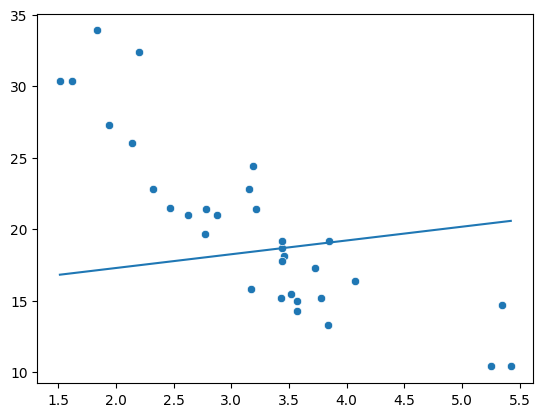

In [28]:
sns.scatterplot(x=X_list, y=y_list)
sns.lineplot(x=X_list, y=y_pred.reshape(-1))
# %% (Statistical) Linear Regression
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X_np, y_list)
print(f"Slope: {reg.coef_}, Bias: {reg.intercept_}")

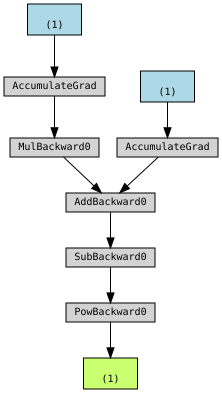

In [31]:
import os
from torchviz import make_dot
os.environ['PATH'] += os.pathsep + 'C:/Program Files (x86)/Graphviz/bin'
make_dot(loss_tensor)

In [30]:
!pip install torchviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli